# EDA and Data Preprocessing


In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
!pip install seaborn --quiet

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 21


In [6]:
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

### Observation

- Dataset contains customer demographic, billing and service information.
- Target variable is Churn.
- No duplicate rows are expected.

In [13]:
df["TotalCharges"].dtype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.isnull().sum()
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Missing Value Treatment

Blank values in TotalCharges were converted to NaN and replaced using the median since TotalCharges is a continuous numerical variable.

In [14]:
df.drop("customerID", axis=1, inplace=True)

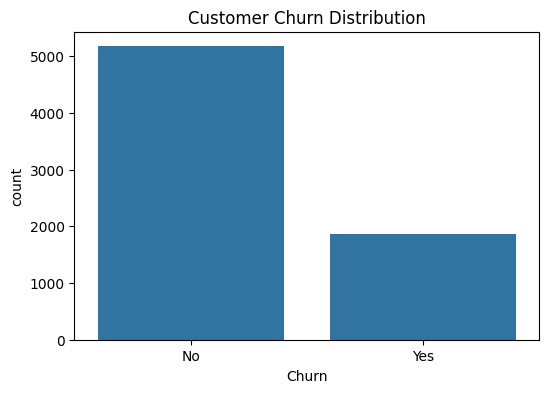

,proportion
Churn,
No,73.463013
Yes,26.536987


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()
df["Churn"].value_counts(normalize=True)*100

The dataset is slightly imbalanced.
Most customers do not churn.

In [17]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

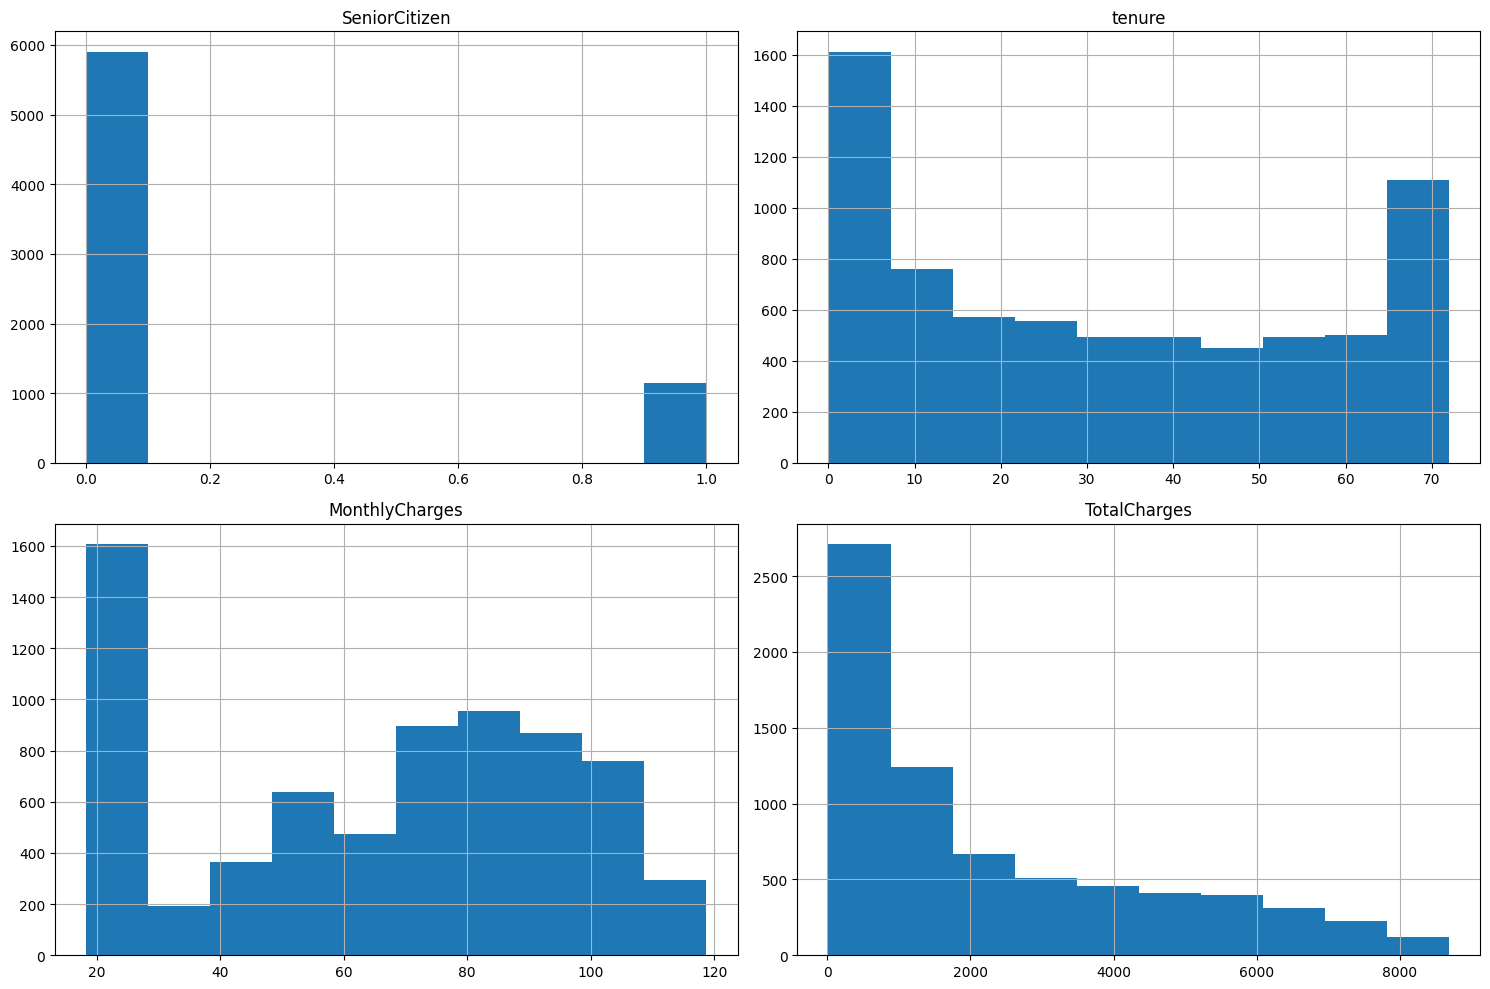

In [18]:
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

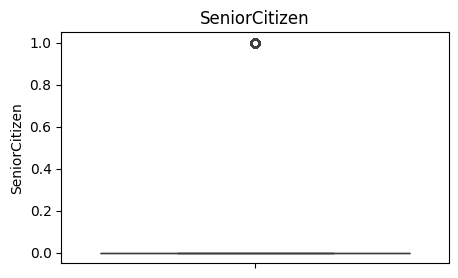

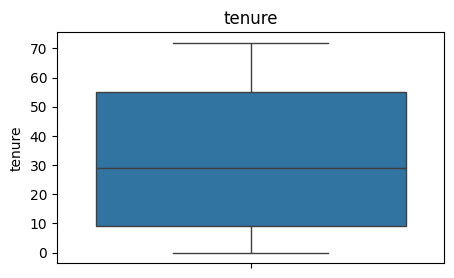

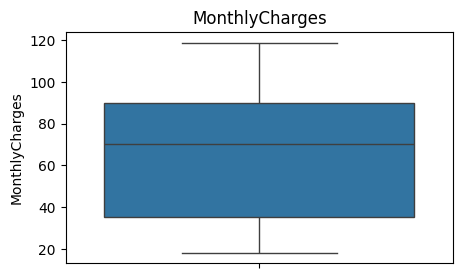

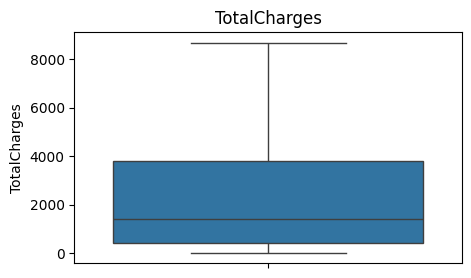

In [19]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [20]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

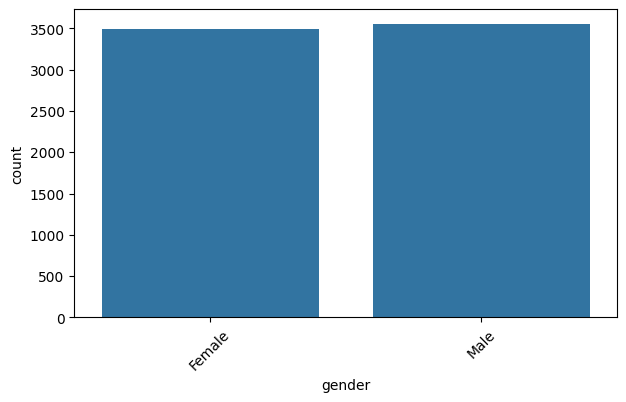

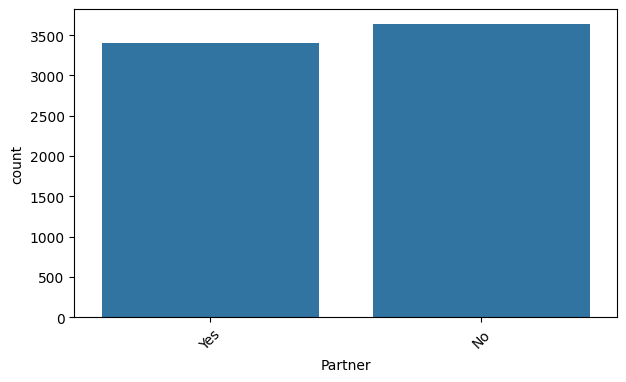

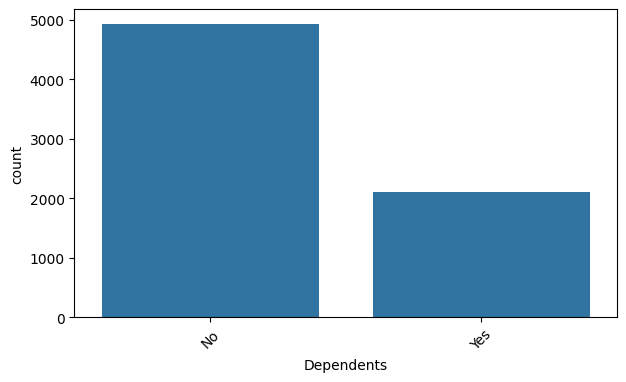

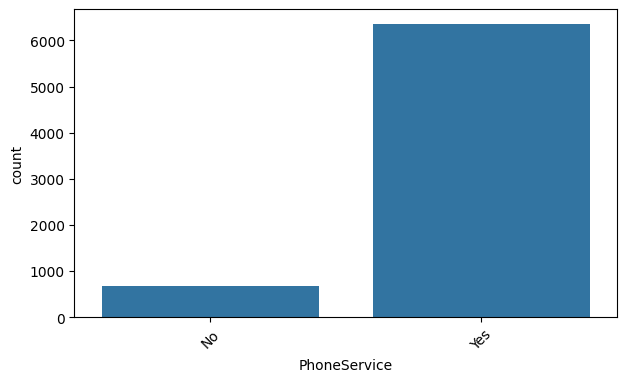

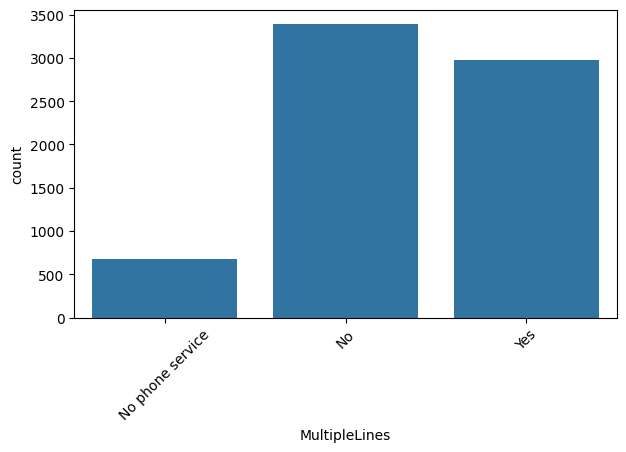

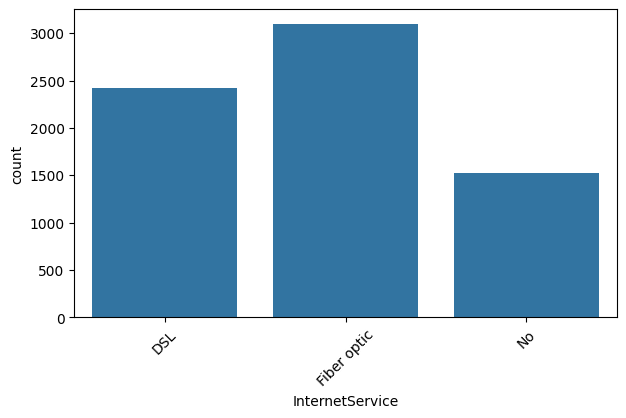

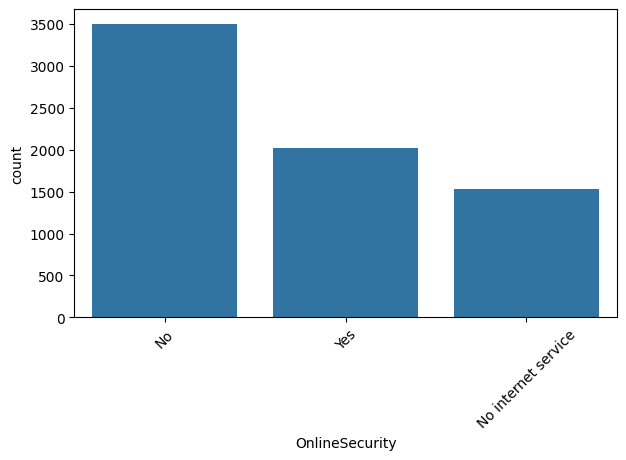

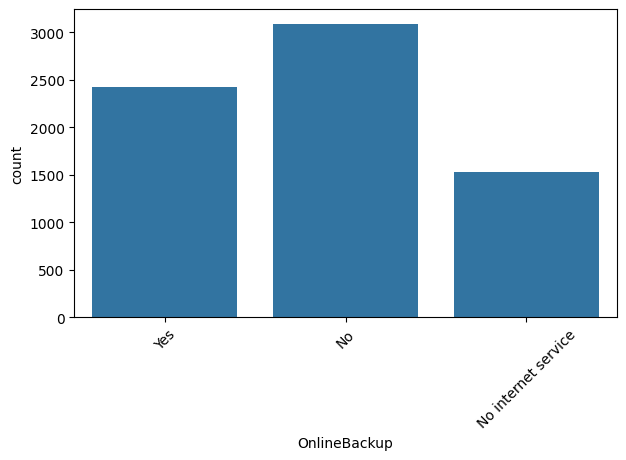

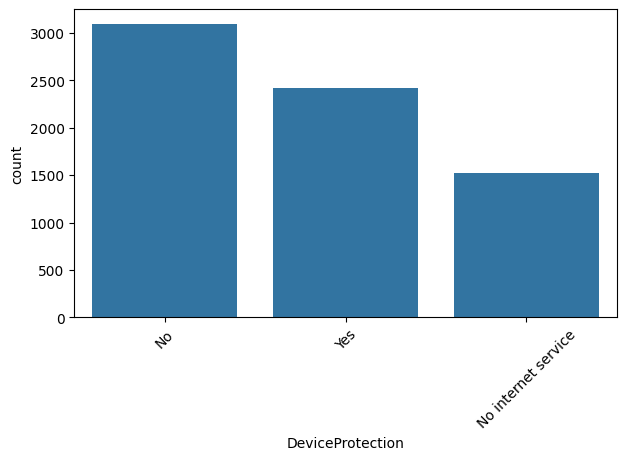

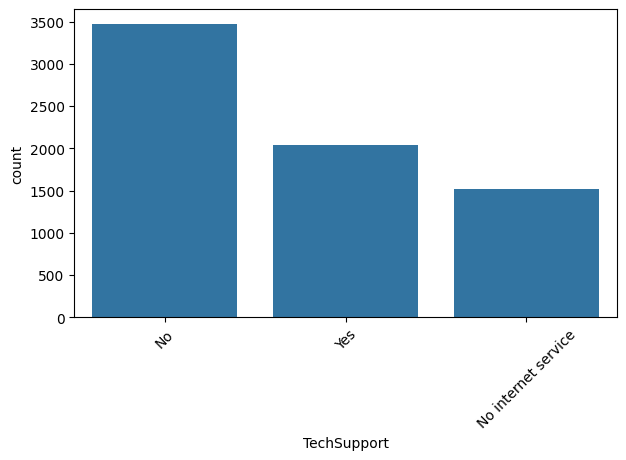

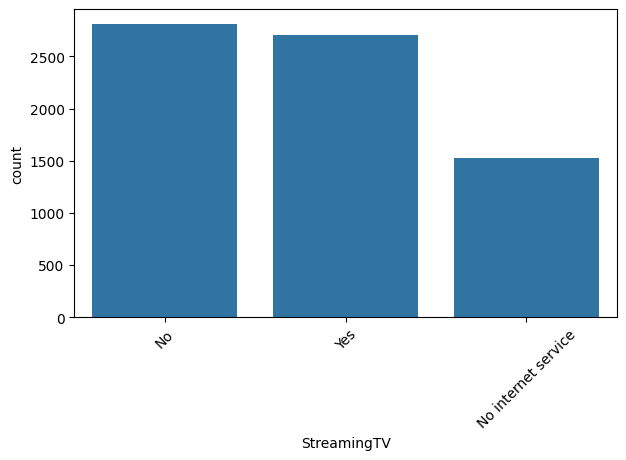

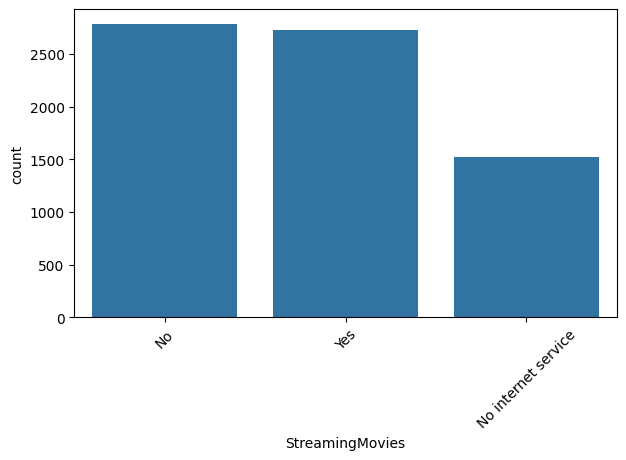

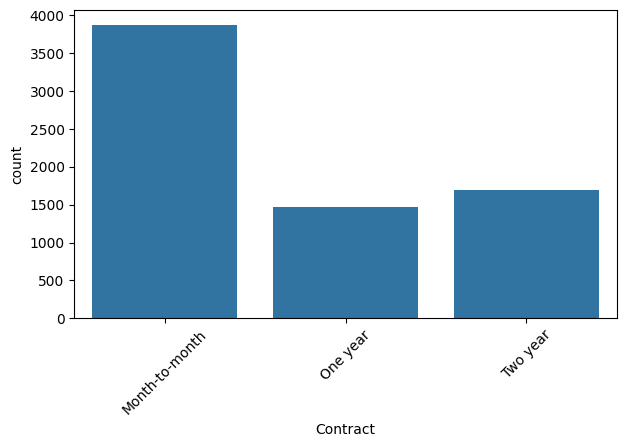

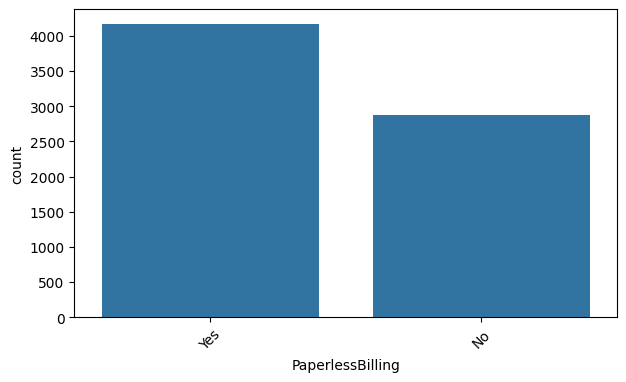

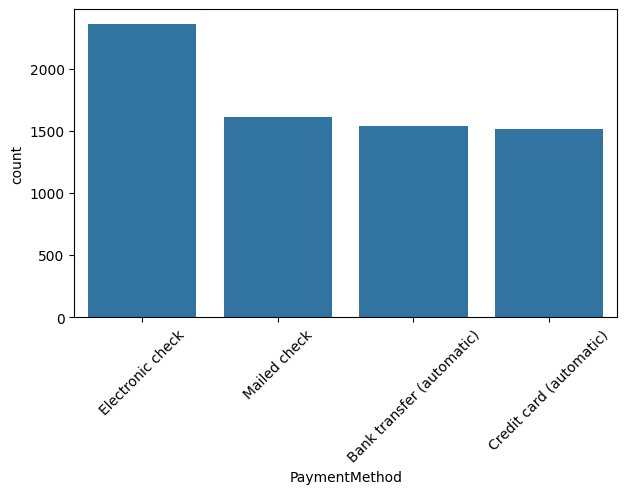

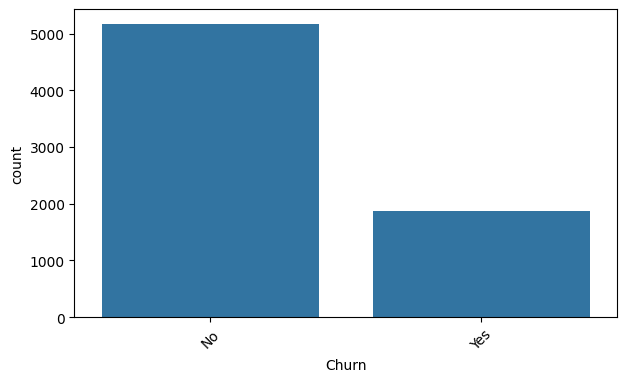

In [21]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

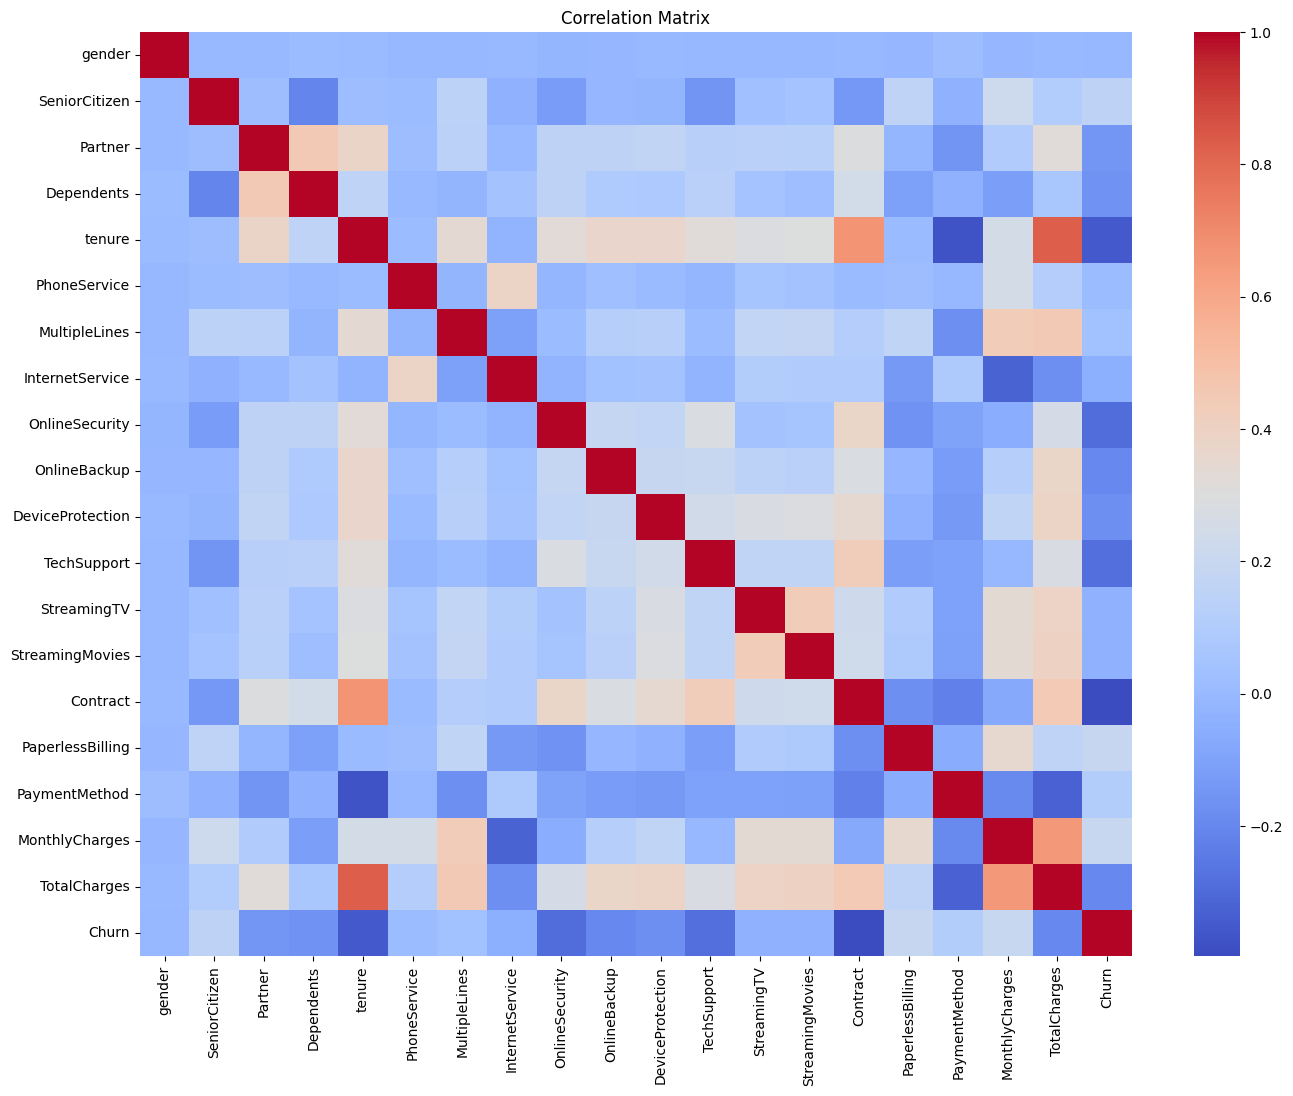

In [22]:
temp = df.copy()

le = LabelEncoder()
for col in temp.columns:
    if temp[col].dtype=='object':
        temp[col]=le.fit_transform(temp[col])

plt.figure(figsize=(16,12))
sns.heatmap(temp.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Correlation heatmap provides an initial understanding of relationships among variables. Strongly correlated variables may be candidates for feature selection.

In [23]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [24]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.994242
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.173244
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-0.959674
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.194766
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-0.940470


In [26]:
processed = X_scaled.copy()
processed["Churn"] = y
processed.to_csv("processed_telco.csv", index=False)

processed.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.994242,0
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.173244,0
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-0.959674,1
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.194766,0
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-0.940470,1


# Feature Selection

1. Correlation Filtering
2. Recursive Feature Elimination (RFE)
3. Random Forest Feature Importance

In [27]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

## Correlation Filtering

Highly correlated features often provide similar information. Removing one of the correlated features can reduce redundancy without significantly affecting prediction performance.

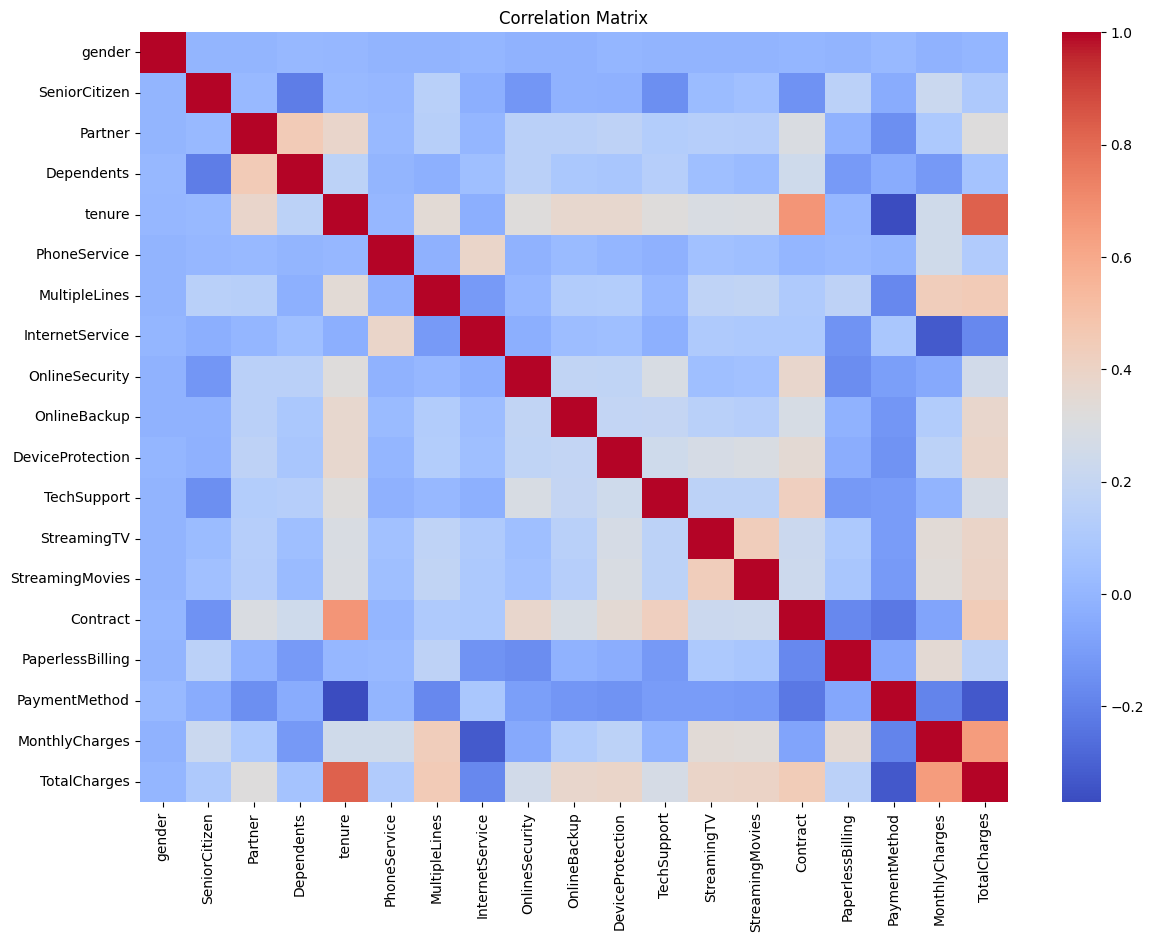

In [28]:
corr_matrix = X.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [29]:
threshold = 0.85

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Highly Correlated Features:")
print(to_drop)

Highly Correlated Features:
[]


In [30]:
X_corr = X.drop(columns=to_drop)
print("Original Shape :", X.shape)
print("Reduced Shape :", X_corr.shape)

Original Shape : (7043, 19)
Reduced Shape : (7043, 19)


### Observation

Features having correlation greater than 0.85 were removed.

This reduces redundancy while preserving most predictive information.

## Recursive Feature Elimination

RFE repeatedly trains a model and removes the least important feature until the desired number of features remains.

In [31]:
dt = DecisionTreeClassifier(random_state=42)

In [32]:
rfe = RFE(
    estimator=dt,
    n_features_to_select=10
)
rfe.fit(X_scaled, y)

selected_features = X.columns[rfe.support_]
print("Selected Features:")
for feature in selected_features:
    print(feature)

X_rfe = X_scaled[selected_features]
print(X_rfe.shape)

ranking = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfe.ranking_
})
ranking.sort_values(
    by="Ranking",
    inplace=True
)
ranking

Selected Features:
gender
tenure
MultipleLines
InternetService
OnlineSecurity
DeviceProtection
Contract
PaymentMethod
MonthlyCharges
TotalCharges
(7043, 10)


,Feature,Ranking
0,gender,1
7,InternetService,1
6,MultipleLines,1
4,tenure,1
10,DeviceProtection,1
14,Contract,1
8,OnlineSecurity,1
16,PaymentMethod,1
17,MonthlyCharges,1
18,TotalCharges,1


## Feature Importance

Random Forest estimates the importance of each feature based on its contribution to reducing impurity across all trees.

In [33]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_scaled, y)

RandomForestClassifier(random_state=42)

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)
importance

,Feature,Importance
18,TotalCharges,0.188243
17,MonthlyCharges,0.181344
4,tenure,0.158132
14,Contract,0.079598
16,PaymentMethod,0.051067
8,OnlineSecurity,0.045266
11,TechSupport,0.043398
0,gender,0.027768
7,InternetService,0.027341
9,OnlineBackup,0.027158


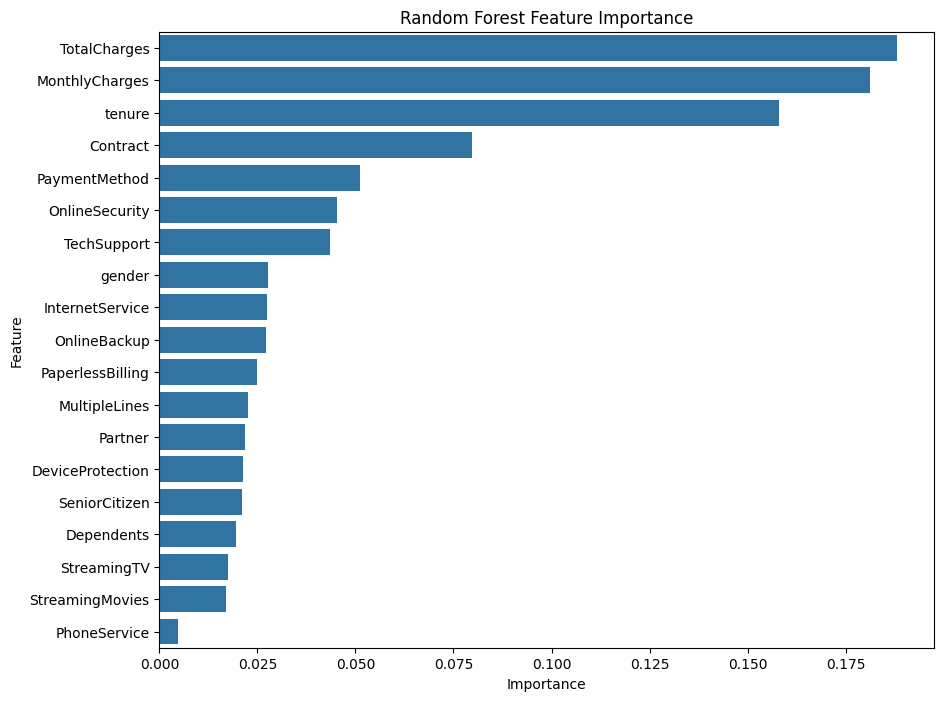

In [35]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.show()

In [36]:
top_features = importance.head(10)["Feature"]
print(top_features)

18       TotalCharges
17     MonthlyCharges
4              tenure
14           Contract
16      PaymentMethod
8      OnlineSecurity
11        TechSupport
0              gender
7     InternetService
9        OnlineBackup
Name: Feature, dtype: object


In [37]:
X_importance = X_scaled[top_features]
print(X_importance.shape)

(7043, 10)


In [38]:
comparison = pd.DataFrame({
    "Dataset":[
        "Original",
        "Correlation Filter",
        "RFE",
        "Feature Importance"
    ],
    "Number of Features":[
        X.shape[1],
        X_corr.shape[1],
        X_rfe.shape[1],
        X_importance.shape[1]
    ]
})
comparison

,Dataset,Number of Features
0,Original,19
1,Correlation Filter,19
2,RFE,10
3,Feature Importance,10


In [39]:
X_corr.to_csv("correlation_features.csv", index=False)
X_rfe.to_csv("rfe_features.csv", index=False)
X_importance.to_csv("feature_importance.csv", index=False)

# Model Training and Comparison

In this section, we compare two machine learning algorithms:

1. Decision Tree
2. Support Vector Machine (SVM)

Each algorithm is trained using:

• Full Feature Set

• RFE Feature Set

Five-fold Cross Validation is used to obtain reliable estimates of model performance.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import time

In [41]:
# Train-Test Split (Full Features)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
# Train-Test Split (RFE Features)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rfe,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
results = []

In [44]:
def evaluate_model(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test,
                   feature_name):
    start = time.time()

    model.fit(X_train, y_train)
    training_time = time.time() - start
    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:,1]
    else:
        probabilities = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc = roc_auc_score(y_test, probabilities)
    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    results.append({
        "Algorithm": model.__class__.__name__,
        "Feature Set": feature_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc,
        "CV Accuracy": cv.mean(),
        "Training Time": training_time
    })

    print(model.__class__.__name__)
    print(classification_report(y_test,predictions))
    print("Confusion Matrix")
    print(confusion_matrix(y_test,predictions))

In [45]:
# Decision Tree (Full Features)
dt = DecisionTreeClassifier(random_state=42)
evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test,
    "Full Features"
)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409

Confusion Matrix
[[835 200]
 [180 194]]


In [46]:
# Decision Tree (RFE Features)
dt_rfe = DecisionTreeClassifier(random_state=42)
evaluate_model(
    dt_rfe,
    Xr_train,
    Xr_test,
    yr_train,
    yr_test,
    "RFE Features"
)

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.51      0.51      0.51       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409

Confusion Matrix
[[849 186]
 [184 190]]


In [47]:
# Support Vector Machine (Full Features)
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

evaluate_model(
    svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Full Features"
)

SVC
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix
[[939  96]
 [195 179]]


In [48]:
# Support Vector Machine (Full Features)
svm_rfe = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

evaluate_model(
    svm_rfe,
    Xr_train,
    Xr_test,
    yr_train,
    yr_test,
    "RFE Features"
)

SVC
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

Confusion Matrix
[[939  96]
 [208 166]]


In [49]:
comparison = pd.DataFrame(results)
comparison

,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,Training Time
0,DecisionTreeClassifier,Full Features,0.730305,0.492386,0.518717,0.505208,0.662526,0.737307,0.045051
1,DecisionTreeClassifier,RFE Features,0.737402,0.505319,0.508021,0.506667,0.669415,0.727723,0.031677
2,SVC,Full Features,0.793471,0.650909,0.478610,0.551618,0.790907,0.798898,5.201951
3,SVC,RFE Features,0.784244,0.633588,0.443850,0.522013,0.797902,0.790023,4.668998


In [50]:
comparison.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)
comparison

,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,Training Time
2,SVC,Full Features,0.793471,0.650909,0.478610,0.551618,0.790907,0.798898,5.201951
3,SVC,RFE Features,0.784244,0.633588,0.443850,0.522013,0.797902,0.790023,4.668998
1,DecisionTreeClassifier,RFE Features,0.737402,0.505319,0.508021,0.506667,0.669415,0.727723,0.031677
0,DecisionTreeClassifier,Full Features,0.730305,0.492386,0.518717,0.505208,0.662526,0.737307,0.045051


In [51]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

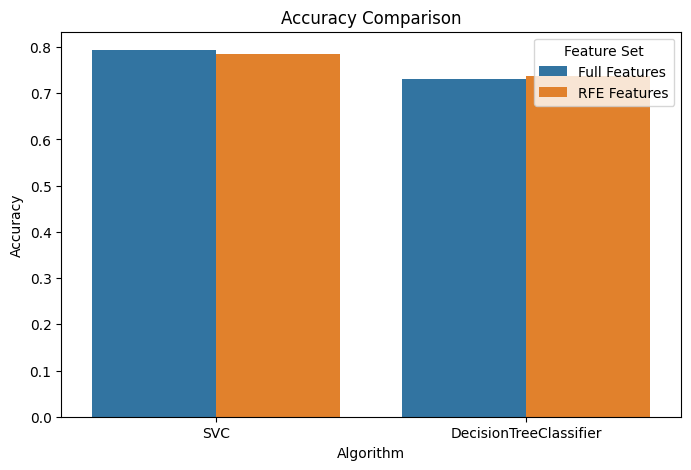

In [52]:
# Plot Accuracy Comparison
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Accuracy",
    hue="Feature Set"
)
plt.title("Accuracy Comparison")
plt.show()

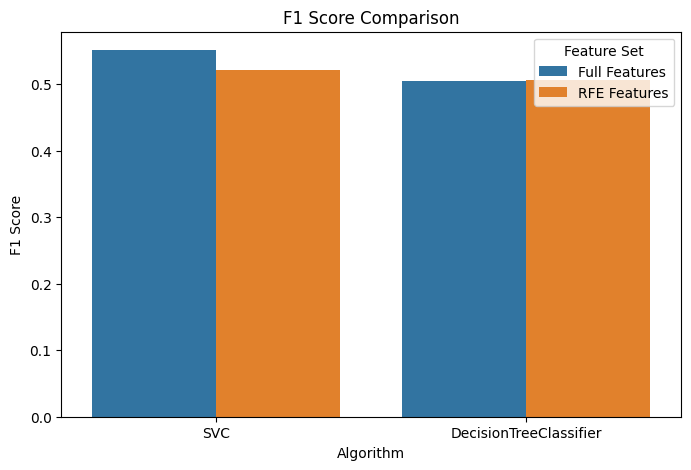

In [53]:
# Plot F1 Score
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Algorithm",
    y="F1 Score",
    hue="Feature Set"
)
plt.title("F1 Score Comparison")
plt.show()

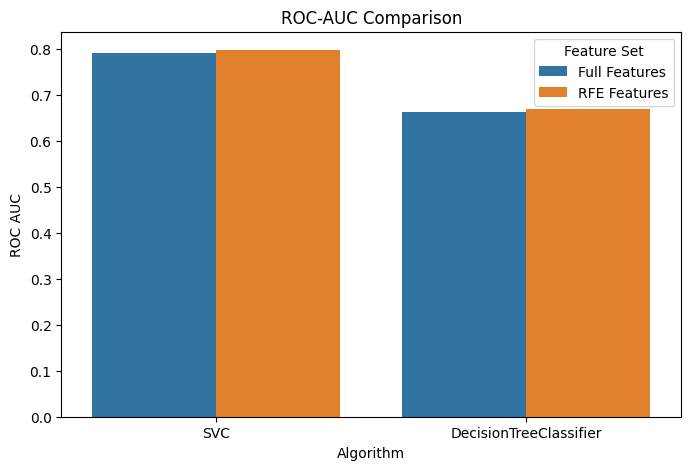

In [54]:
# Plot ROC-AUC
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Algorithm",
    y="ROC AUC",
    hue="Feature Set"
)
plt.title("ROC-AUC Comparison")
plt.show()

# Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV with 5-fold Cross Validation to identify the optimal model configuration.



In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import ConfusionMatrixDisplay

In [56]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

The following hyperparameters are tuned:

- C (Regularization Parameter)
- Kernel Type
- Gamma

In [57]:
svm_model = SVC(
    probability=True,
    random_state=42
)

In [58]:
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [59]:
grid_search.fit(Xr_train, yr_train)
# We use the RFE feature set, since it generally contains the most relevant features

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

In [60]:
print("Best Parameters")
print(grid_search.best_params_)

print("Best Cross Validation Accuracy")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(Xr_test)
y_prob = best_model.predict_proba(Xr_test)[:,1]

Best Parameters
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy
0.7932170319668528


In [61]:
accuracy = accuracy_score(yr_test, y_pred)
precision = precision_score(yr_test, y_pred)
recall = recall_score(yr_test, y_pred)
f1 = f1_score(yr_test, y_pred)
roc_auc = roc_auc_score(yr_test, y_prob)

In [62]:
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc_auc)

Accuracy : 0.7863733144073811
Precision : 0.6237288135593221
Recall : 0.4919786096256685
F1 Score : 0.5500747384155455
ROC AUC : 0.808824821101036


In [63]:
print(classification_report(
    yr_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



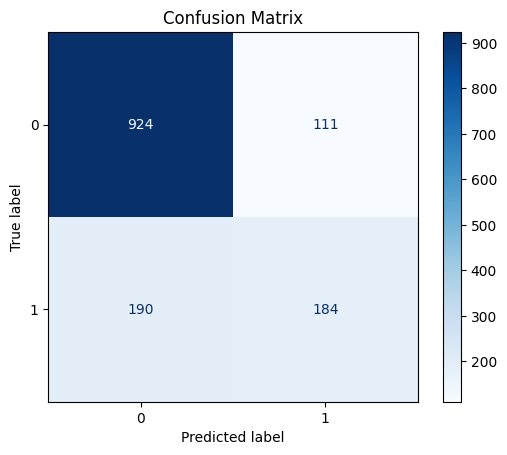

In [64]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    Xr_test,
    yr_test,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()

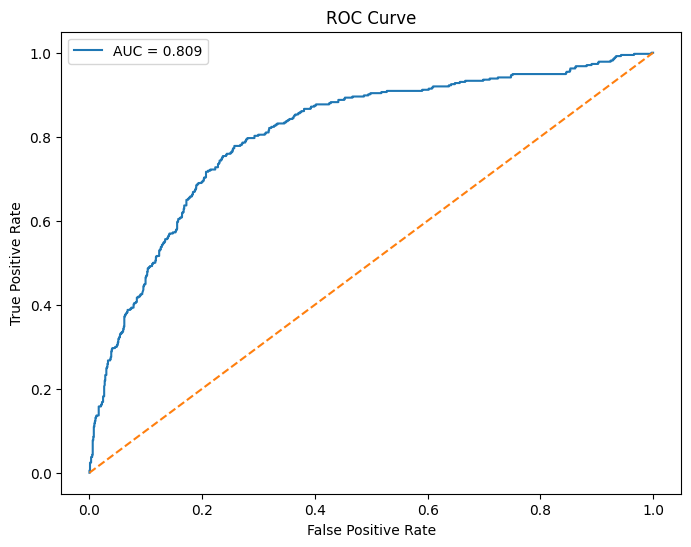

In [65]:
fpr, tpr, threshold = roc_curve(
    yr_test,
    y_prob
)
roc_score = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label="AUC = {:.3f}".format(roc_score)
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [66]:
print("Number of Features")
print(X_rfe.shape[1])

Number of Features
10


In [67]:
comparison
tuned_result = pd.DataFrame({
    "Algorithm":["SVM (Tuned)"],
    "Feature Set":["RFE"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1 Score":[f1],
    "ROC AUC":[roc_auc],
    "CV Accuracy":[grid_search.best_score_],
    "Training Time":["GridSearch"]
})

final_results = pd.concat(
    [comparison, tuned_result],
    ignore_index=True
)
final_results

,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,Training Time
0,SVC,Full Features,0.793471,0.650909,0.478610,0.551618,0.790907,0.798898,5.201951
1,SVC,RFE Features,0.784244,0.633588,0.443850,0.522013,0.797902,0.790023,4.668998
2,DecisionTreeClassifier,RFE Features,0.737402,0.505319,0.508021,0.506667,0.669415,0.727723,0.031677
3,DecisionTreeClassifier,Full Features,0.730305,0.492386,0.518717,0.505208,0.662526,0.737307,0.045051
4,SVM (Tuned),RFE,0.786373,0.623729,0.491979,0.550075,0.808825,0.793217,GridSearch


In [68]:
final_results.to_csv(
    "final_model_results.csv",
    index=False
)

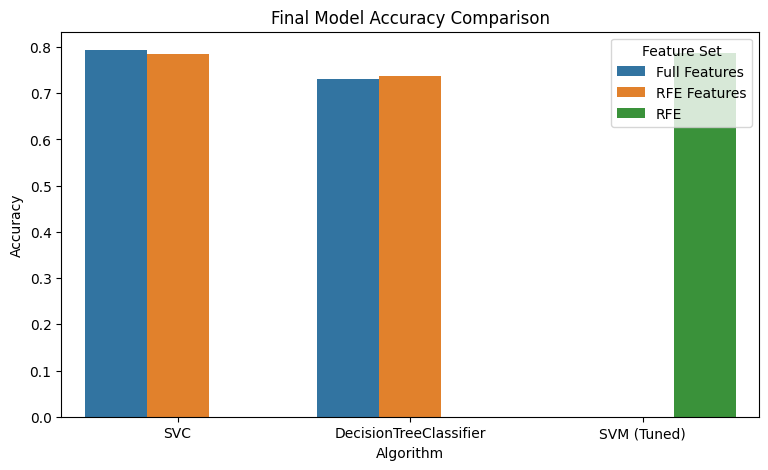

In [69]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=final_results,
    x="Algorithm",
    y="Accuracy",
    hue="Feature Set"
)
plt.title("Final Model Accuracy Comparison")
plt.show()

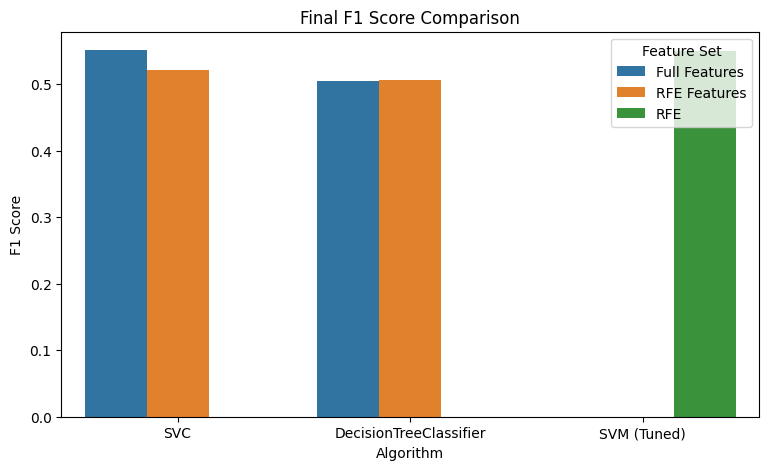

In [70]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=final_results,
    x="Algorithm",
    y="F1 Score",
    hue="Feature Set"
)
plt.title("Final F1 Score Comparison")
plt.show()

In [71]:
import joblib
joblib.dump(
    best_model,
    "best_svm_model.pkl"
)

['best_svm_model.pkl']

# Final Results

In [72]:
print("Final Model Comparison")
final_results

Final Model Comparison


,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,Training Time
0,SVC,Full Features,0.793471,0.650909,0.478610,0.551618,0.790907,0.798898,5.201951
1,SVC,RFE Features,0.784244,0.633588,0.443850,0.522013,0.797902,0.790023,4.668998
2,DecisionTreeClassifier,RFE Features,0.737402,0.505319,0.508021,0.506667,0.669415,0.727723,0.031677
3,DecisionTreeClassifier,Full Features,0.730305,0.492386,0.518717,0.505208,0.662526,0.737307,0.045051
4,SVM (Tuned),RFE,0.786373,0.623729,0.491979,0.550075,0.808825,0.793217,GridSearch


In [80]:
final_results = final_results.sort_values(
    by=["Accuracy", "F1 Score"],
    ascending=False
)
final_results.reset_index(drop=True, inplace=True)
final_results

,Algorithm,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy,Training Time
0,SVC,Full Features,0.793471,0.650909,0.478610,0.551618,0.790907,0.798898,5.201951
1,SVM (Tuned),RFE,0.786373,0.623729,0.491979,0.550075,0.808825,0.793217,GridSearch
2,SVC,RFE Features,0.784244,0.633588,0.443850,0.522013,0.797902,0.790023,4.668998
3,DecisionTreeClassifier,RFE Features,0.737402,0.505319,0.508021,0.506667,0.669415,0.727723,0.031677
4,DecisionTreeClassifier,Full Features,0.730305,0.492386,0.518717,0.505208,0.662526,0.737307,0.045051


In [74]:
best = final_results.iloc[0]
print("Best Model Details")

print("-----------------------------------")

print("Algorithm :", best["Algorithm"])
print("Feature Set :", best["Feature Set"])
print("Accuracy :", round(best["Accuracy"],4))
print("Precision :", round(best["Precision"],4))
print("Recall :", round(best["Recall"],4))
print("F1 Score :", round(best["F1 Score"],4))
print("ROC AUC :", round(best["ROC AUC"],4))

Best Model Details
-----------------------------------
Algorithm : SVC
Feature Set : Full Features
Accuracy : 0.7935
Precision : 0.6509
Recall : 0.4786
F1 Score : 0.5516
ROC AUC : 0.7909


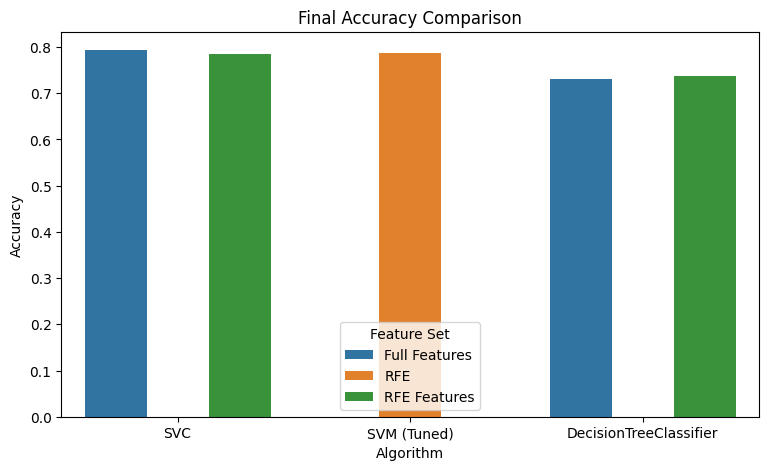

In [75]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=final_results,
    x="Algorithm",
    y="Accuracy",
    hue="Feature Set"
)
plt.title("Final Accuracy Comparison")
plt.show()

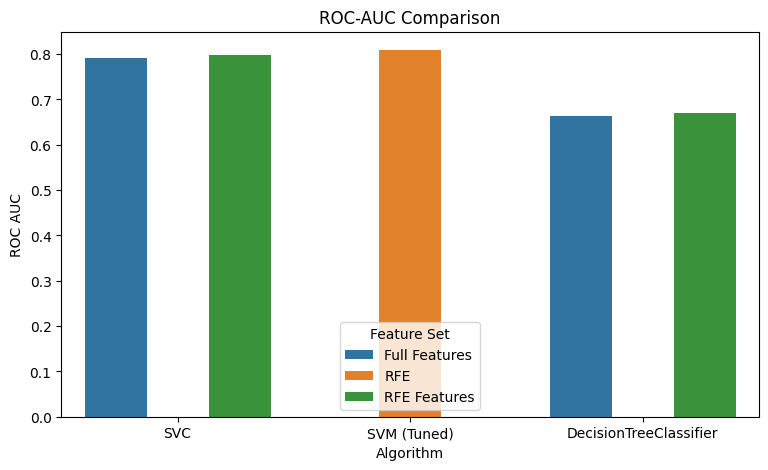

In [76]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=final_results,
    x="Algorithm",
    y="ROC AUC",
    hue="Feature Set"
)
plt.title("ROC-AUC Comparison")
plt.show()

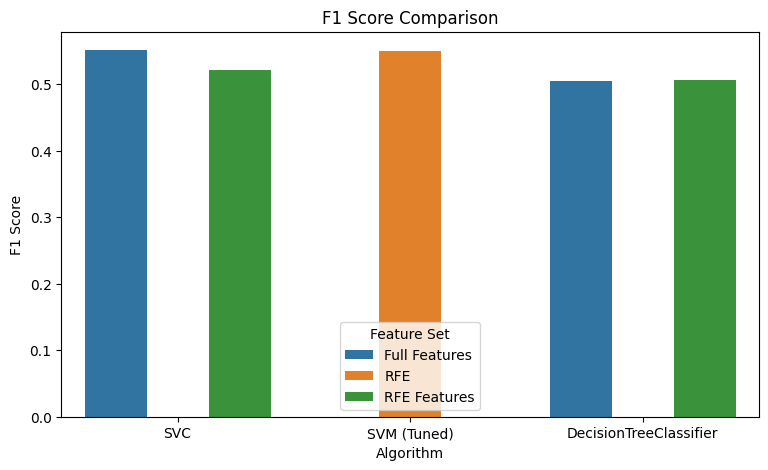

In [77]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=final_results,
    x="Algorithm",
    y="F1 Score",
    hue="Feature Set"
)
plt.title("F1 Score Comparison")
plt.show()

In [78]:
print("Top Features Selected by RFE")
for feature in selected_features:
    print(feature)

Top Features Selected by RFE
gender
tenure
MultipleLines
InternetService
OnlineSecurity
DeviceProtection
Contract
PaymentMethod
MonthlyCharges
TotalCharges
